# **Complete repository step-by-step diagnostics. (Optimization Modules)**

In [1]:
# Add in validation utilities for testing and diagnostics.

from typing import Any, Callable, Optional
from IPython.display import Image
from rich import print 

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

## Rehydrate the main setup code to ensure all modules are loaded for diagnostics

In [2]:
"""
# Iligan City

import yaml
from dotenv import load_dotenv

from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

load_dotenv()

with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

CACHE_DIR = cfg["global"]["cache_dir"]

print("[OPTIMIZATION SETUP] Loading CityGraph from cache...")
city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg.get("landmarks"),
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    cache_dir=CACHE_DIR,
    cache_prefix=city_graph_cfg["cache_prefix"]
)

print("[OPTIMIZATION SETUP] Initializing Direct Demand Sampler...")
ddm_params = cfg["ddm"].copy()
ddm_params["cache_dir"] = CACHE_DIR

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**ddm_params),
    verbose=False
)

print("[OPTIMIZATION SETUP] Initializing Route Generator...")
generator = RouteGenerator(
    city_graph=city,
    sampler=sampler,
    verbose=False
)

print("[OPTIMIZATION SETUP] Building TravelGraph with fresh routes...")
num_routes = cfg.get("simulation", {}).get("num_routes", 5)
tg = TravelGraph(
    cg=city,
    config=cfg["travel_graph"],
    route_generator=generator,
    n_routes=num_routes,
    n_points=5
)
routes = tg.routes

print(f"[OPTIMIZATION SETUP] Ready. Base modules, {len(routes)} fresh routes, and TravelGraph loaded.")
"""

'\n# Iligan City\n\nimport yaml\nfrom dotenv import load_dotenv\n\nfrom utils.city_graph import CityGraph\nfrom utils.direct_demand_sampler import DirectDemandSampler, DDMConfig\nfrom utils.route import RouteGenerator\nfrom utils.travel_graph import TravelGraph\n\nload_dotenv()\n\nwith open(\'configs/iligan_configs.yaml\', \'r\') as f:\n    cfg = yaml.safe_load(f)\n\nCACHE_DIR = cfg["global"]["cache_dir"]\n\nprint("[OPTIMIZATION SETUP] Loading CityGraph from cache...")\ncity_graph_cfg = cfg["city_graph"]\ncity = CityGraph(\n    bbox=tuple(city_graph_cfg["bbox"]),\n    name=city_graph_cfg["name"],\n    landmarks=city_graph_cfg.get("landmarks"),\n    pbf_path=city_graph_cfg["pbf_path"],\n    use_api=False,\n    cache_dir=CACHE_DIR,\n    cache_prefix=city_graph_cfg["cache_prefix"]\n)\n\nprint("[OPTIMIZATION SETUP] Initializing Direct Demand Sampler...")\nddm_params = cfg["ddm"].copy()\nddm_params["cache_dir"] = CACHE_DIR\n\nsampler = DirectDemandSampler(\n    city=city,\n    config=DDMCon

In [3]:
# Toy City

from utils.toy_city import toy_setup_from_yaml
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

print("[OPTIMIZATION SETUP] Loading toy city...")
city, sampler, cfg = toy_setup_from_yaml('configs/toy_city_configs.yaml', verbose=True)

print("[OPTIMIZATION SETUP] Initializing Route Generator...")
generator = RouteGenerator(
    city_graph=city,
    sampler=sampler,
    verbose=False
)

print("[OPTIMIZATION SETUP] Building TravelGraph with fresh routes...")
num_routes = cfg.get("simulation", {}).get("num_routes", 5)
tg = TravelGraph(
    cg=city,
    config=cfg["travel_graph"],
    route_generator=generator,
    n_routes=num_routes,
    n_points=5
)
routes = tg.routes

print(f"[OPTIMIZATION SETUP] Ready. Base modules, {len(routes)} fresh routes, and TravelGraph loaded.")


[OPTIMIZATION SETUP] Loading toy city...

[TOY CITY] Building 50×50 grid…
CityGraph(ToyCity(50×50)) | Nodes: 2500 | Edges: 9800 (Drivable: 9800) | Landmarks: []
[TOY DDM] Built demand surface over 2500 nodes (2500 drivable) using 5 hotspots.
  · [Market District]  weight=12.0  nearest_node_prob=0.00075
  · [Jeepney Terminal]  weight=9.0  nearest_node_prob=0.00056
  · [University]  weight=6.0  nearest_node_prob=0.00038
  · [Residential North]  weight=2.0  nearest_node_prob=0.00013
  · [Industrial South]  weight=4.0  nearest_node_prob=0.00025
  Demand contrast (max/min prob): 6.0×


[OPTIMIZATION SETUP] Initializing Route Generator...

[OPTIMIZATION SETUP] Building TravelGraph with fresh routes...

[OPTIMIZATION SETUP] Ready. Base modules, 5 fresh routes, and TravelGraph loaded.

## **Pheromone** (in pheromone.py, using the new SimulationEvaluator in simulation.py)

[VALIDATED] Assemble Baseline Simulation: Executed successfully.

[VALIDATED] Evaluate Baseline Route System: Executed successfully.

[RESULTS] Fitness Score:          -9851321.26

[RESULTS] Completed Journeys:     310

[RESULTS] Incomplete Journeys:    681

[VALIDATED] Initialize PheromoneMatrix: Executed successfully.

[VISUALIZATION] Rendering Route Infrastructure...

[VISUALIZATION] Rendering Pheromone Demand Spectrum...

[VALIDATED] Draw Pheromone Matrix: Executed successfully.

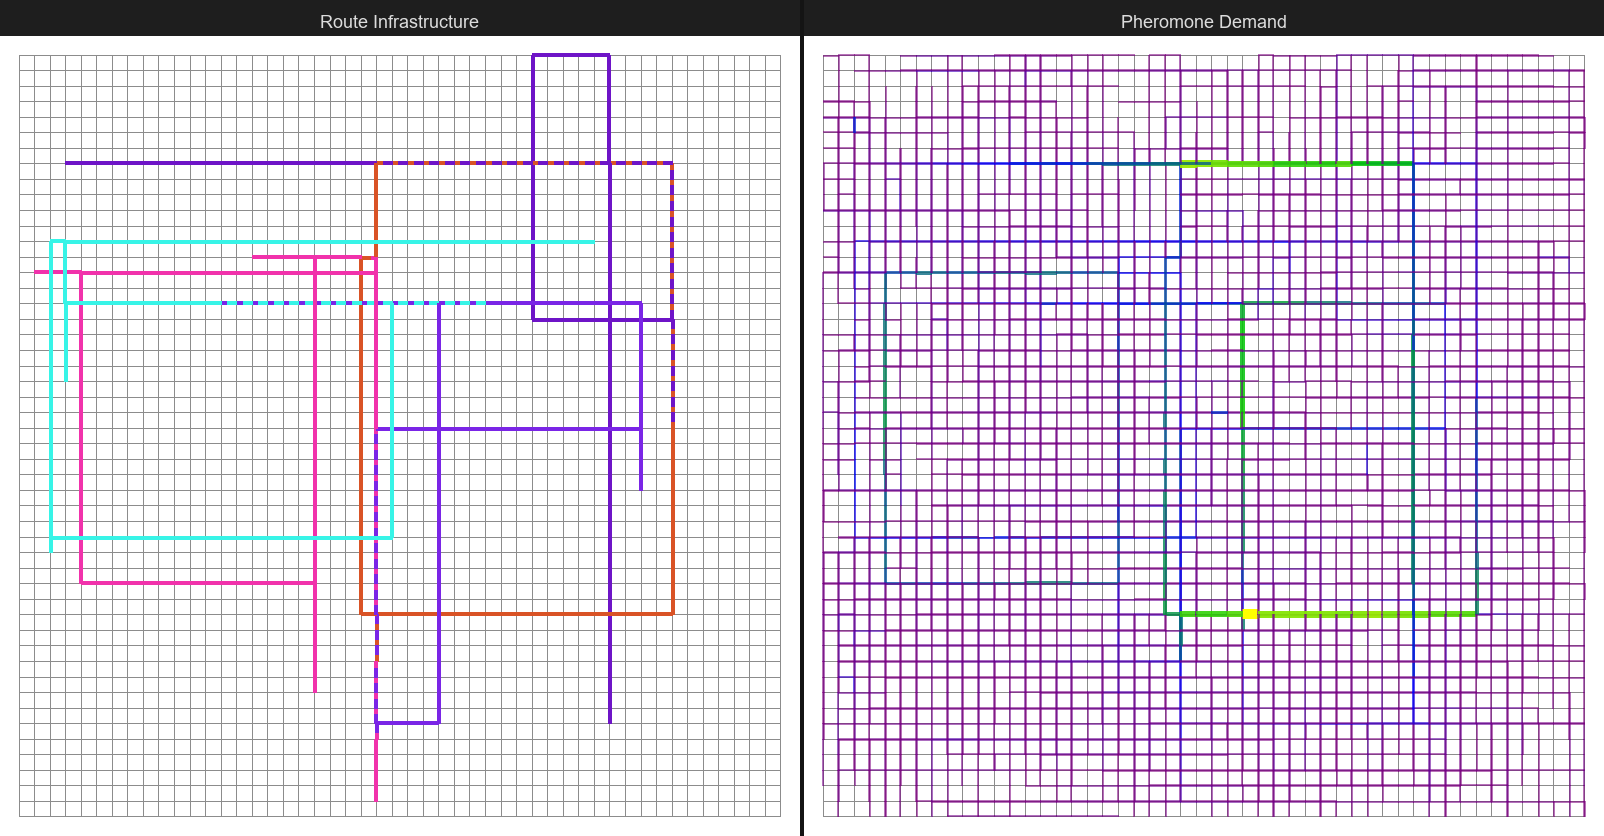

In [4]:
from utils.simulation import Simulation
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.passenger_generator import PassengerGenerator
from utils.pheromone import PheromoneMatrix
from utils.route import RouteSystem
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont

sim_cfg = cfg.get("simulation", {})
jeep_speed       = sim_cfg.get("jeep_speed_kmh", 40.0)
jeep_capacity    = sim_cfg.get("jeep_capacity", 16)
weight_tol       = sim_cfg.get("weight_tolerance", 50.0)
seconds_per_tick = sim_cfg.get("seconds_per_tick", 1)
total_jeeps      = sim_cfg.get("total_allocatable_jeeps", 25)
jeeps_per_route  = max(1, total_jeeps // len(routes))

# 1. Build and run the simulation directly so result.jeep_system stays intact.
jeeps = []
for route in routes:
    for _ in range(jeeps_per_route):
        start_coord = (route.path[0].start.lon, route.path[0].start.lat)
        jeeps.append(Jeep(route, curr_pos=start_coord, speed=jeep_speed,
                          max_capacity=jeep_capacity, seconds_per_tick=seconds_per_tick))

jeep_system = JeepSystem(
    jeeps=jeeps,
    routes=routes,
    weight_tolerance=weight_tol,
    equidistant_spawn=True
)

passenger_generator = PassengerGenerator(
    tg=tg,
    sampler=sampler,
    rate_per_hour=sim_cfg.get("spawn_rate_per_hour", 40.0),
    stdev=sim_cfg.get("spawn_stdev", 5.0),
    speed=sim_cfg.get("passenger_speed_kmh", 5.0),
    seconds_per_tick=seconds_per_tick
)

sim = validate_call(
    "Assemble Baseline Simulation",
    True,
    Simulation,
    city_query=city.name,
    bounds=city.get_bounds(),
    jeep_system=jeep_system,
    passenger_generator=passenger_generator,
    max_ticks=sim_cfg.get("num_ticks", 300),
    beta_penalty=cfg.get("BETA_PENALTY", 2.0),
    alpha_std_penalty=cfg.get("ALPHA_STD_PENALTY", 0.5),
    config=cfg
)

result = validate_call("Evaluate Baseline Route System", True, sim.run)

if result:
    print(f"[RESULTS] Fitness Score:          {result.fitness_score:.2f}")
    print(f"[RESULTS] Completed Journeys:     {result.metrics['completed_count']}")
    print(f"[RESULTS] Incomplete Journeys:    {result.metrics['incomplete_count']}")

    # 2. Extract active edges and initialize pheromones.
    active_network_edges = set()
    for path, _ in result.recorded_paths:
        if path:
            active_network_edges.update(path)
    for route in routes:
        active_network_edges.update(route.path)

    pheromones = validate_call(
        "Initialize PheromoneMatrix",
        True,
        PheromoneMatrix,
        all_edges=active_network_edges,
        config=cfg,
        sim_result=result
    )

    # 3. Render both maps independently on clean base copies.
    context  = city.get_bounds()
    SIZE     = 800
    base_map = city.draw(size=SIZE)

    # — Left panel: route infrastructure —
    rs = RouteSystem()
    for r in routes:
        rs.add_route(r)

    print("[VISUALIZATION] Rendering Route Infrastructure...")
    route_map = rs.draw(context, base_map.copy(), line_width=4, dash_length=10)

    # — Right panel: pheromone demand spectrum —
    print("[VISUALIZATION] Rendering Pheromone Demand Spectrum...")
    pheromone_map = validate_call(
        "Draw Pheromone Matrix",
        True,
        pheromones.draw,
        context,
        base_map.copy(),   # fresh base — no routes drawn on top
    )

    # 4. Stitch side-by-side with labels.
    def _label(img: Image.Image, text: str) -> Image.Image:
        """Adds a centered title bar above an image."""
        BAR_H = 36
        out = Image.new("RGB", (img.width, img.height + BAR_H), (30, 30, 30))
        out.paste(img, (0, BAR_H))
        draw = ImageDraw.Draw(out)
        try:
            font = ImageFont.truetype("arial.ttf", 18)
        except IOError:
            font = ImageFont.load_default()
        bbox = draw.textbbox((0, 0), text, font=font)
        tx = (img.width - (bbox[2] - bbox[0])) // 2
        ty = (BAR_H - (bbox[3] - bbox[1])) // 2
        draw.text((tx, ty), text, fill=(220, 220, 220), font=font)
        return out

    if pheromone_map:
        left  = _label(route_map,     "Route Infrastructure")
        right = _label(pheromone_map, "Pheromone Demand")

        panel = Image.new("RGB", (left.width + right.width + 4, max(left.height, right.height)), (20, 20, 20))
        panel.paste(left,  (0, 0))
        panel.paste(right, (left.width + 4, 0))

        display(panel)

## **ExperimentConfig and OptimizationState** (in optimizer_config.py)

In [5]:
from utils.optimizer_config import ExperimentConfig, OptimizationState

yaml_path = 'configs/toy_city_configs.yaml'

config = validate_call("Parse YAML Config", True, ExperimentConfig.from_yaml, yaml_path)

if config:
    assert_true(isinstance(config.max_ticks, int), "max_ticks failed integer cast.")
    assert_true(isinstance(config.p_mutation, float), "p_mutation failed float cast.")
    assert_true(isinstance(config.city_bounds, tuple), "city_bounds failed tuple cast.")
    assert_true(len(config.city_bounds) == 4, "city_bounds tuple length invalid.")
    
    print(f"[TEST] BBox Extracted: {config.city_bounds}")
    print(f"[TEST] Total Fleet Registered: {config.total_fleet}")
    print(f"[TEST] Telemetry Export Path: {config.output_root}")

state = validate_call("Initialize OptimizationState", True, OptimizationState)

if state:
    assert_true(state.generation == 1, "State generation default invalid.")
    assert_true(state.best_fitness == float('inf'), "State fitness default invalid.")

[VALIDATED] Parse YAML Config: Executed successfully.

[TEST] BBox Extracted: (124.2, 8.2, 124.25, 8.25)

[TEST] Total Fleet Registered: 20

[TEST] Telemetry Export Path: outputs\toy_runs

[VALIDATED] Initialize OptimizationState: Executed successfully.

## **AdaptiveController** (in optimizer_adaptive.py)

In [6]:
from utils.optimizer_adaptive import AdaptiveController

base_mut = 0.2
limit = 10
expected_cap = 0.8

adaptive = validate_call("Initialize AdaptiveController", True, AdaptiveController, base_mutation=base_mut, stagnation_limit=limit)

if adaptive:
    # 1. Baseline behavior
    mut_0 = adaptive.update(0)
    assert_true(mut_0 == base_mut, f"Expected baseline {base_mut}, got {mut_0}")
    print(f"[TEST] Stagnation 0 -> Mutation Rate: {mut_0:.2f}")

    # 2. Intermediate scaling
    mut_mid = adaptive.update(limit // 2)
    assert_true(mut_mid > base_mut, "Mutation rate did not scale up during stagnation.")
    print(f"[TEST] Stagnation {limit//2} -> Mutation Rate: {mut_mid:.2f}")

    # 3. Limit behavior (Cap)
    mut_max = adaptive.update(limit)
    assert_true(mut_max == expected_cap, f"Expected hard cap {expected_cap}, got {mut_max}")
    print(f"[TEST] Stagnation {limit} -> Mutation Rate: {mut_max:.2f}")

    # 4. Overshoot behavior
    mut_over = adaptive.update(limit + 5)
    assert_true(mut_over == expected_cap, f"Mutation rate exceeded hard cap, got {mut_over}")
    print(f"[TEST] Stagnation overshoot ({limit + 5}) -> Mutation Rate capped at: {mut_over:.2f}")

    # 5. Reset behavior
    mut_reset = adaptive.update(0)
    assert_true(mut_reset == base_mut, "Mutation rate did not reset on improvement.")
    print("[TEST] Stagnation Reset -> Mutation Rate successfully restored to baseline.")

[VALIDATED] Initialize AdaptiveController: Executed successfully.

[TEST] Stagnation 0 -> Mutation Rate: 0.20

[TEST] Stagnation 5 -> Mutation Rate: 0.35

[TEST] Stagnation 10 -> Mutation Rate: 0.80

[TEST] Stagnation overshoot (15) -> Mutation Rate capped at: 0.80

[TEST] Stagnation Reset -> Mutation Rate successfully restored to baseline.

## **TelemetryEngine** (in optimizer_telemetry.py)

In [7]:
import tempfile
import csv
import json
from pathlib import Path
from utils.optimizer_telemetry import TelemetryEngine

# Mock structure to bypass deep dependencies
class MockNode:
    def __init__(self, lat, lon): self.lat, self.lon = lat, lon
class MockEdge:
    def __init__(self):
        self.start = MockNode(8.2, 124.2)
        self.end = MockNode(8.21, 124.21)
class MockRoute:
    def __init__(self): self.path = [MockEdge()]
class MockPheromones:
    def __init__(self): self.tau = {MockEdge(): 2.5}
    def calculate_demand_service_gaps(self, dummy_sys): return {MockEdge(): 6.0}
class MockChromosome:
    def __init__(self, cost):
        self.uid, self.generation, self.cost = "chrom_001", 1, cost
        self.parents = ["P1", "P2"]
        self.routes, self.pheromones = [MockRoute()], MockPheromones()
        self.allocation = {self.routes[0]: 5}

with tempfile.TemporaryDirectory() as tmpdir:
    run_dir = Path(tmpdir)
    bounds = (0.0, 0.0, 0.0, 0.0)
    
    # Run 1: Initialization
    te1 = validate_call("Initialize Telemetry (Run 1)", True, TelemetryEngine, run_dir, bounds)
    validate_call("Log Generation 1", True, te1.log_generation, 1, 100.0, 150.0, 0.2, 0)
    
    # Run 2: Resume Checkpoint
    te2 = validate_call("Initialize Telemetry (Run 2 Resume)", True, TelemetryEngine, run_dir, bounds)
    validate_call("Log Generation 2", True, te2.log_generation, 2, 90.0, 140.0, 0.2, 0)
    
    # Assert rerunnability: Headers (1) + Run 1 (1) + Run 2 (1) = 3 rows
    with open(run_dir / "history.csv", "r") as f:
        rows = list(csv.reader(f))
        assert_true(len(rows) == 3, "Telemetry failed to append; historical data was overwritten.")
        print("[TEST] Historical append validation passed.")

    # Export validation
    chroms = [MockChromosome(100.0), MockChromosome(120.0)]
    validate_call("Export JSON Snapshot", True, te1.export_json_snapshot, 2, 90.0, 110.0, chroms)
    
    json_path = run_dir / "snapshots" / "network_state_gen_2.json"
    assert_true(json_path.exists(), "JSON snapshot was not generated.")
    
    with open(json_path, "r") as f:
        payload = json.load(f)
        assert_true(payload["metadata"]["best_cost"] == 90.0, "JSON payload data mismatch.")
        print("[TEST] JSON structure and API bridging successfully validated.")

[VALIDATED] Initialize Telemetry (Run 1): Executed successfully.

[VALIDATED] Log Generation 1: Executed successfully.

[VALIDATED] Initialize Telemetry (Run 2 Resume): Executed successfully.

[VALIDATED] Log Generation 2: Executed successfully.

[TEST] Historical append validation passed.

[VALIDATED] Export JSON Snapshot: Executed successfully.

[TEST] JSON structure and API bridging successfully validated.